# Практическая работа №5: Элементы регрессионного анализа. Выборочные прямые среднеквадратической регрессии. Корреляционные отношения

Выполнили студенты гр. 2381 Ахметгареев Карим Ильгизович и Самулевич Степан Александрович. Вариант №1.

## Цель работы
Ознакомление с основными положениями метода наименьших квадратов (МНК), со статистическими свойствами МНК-оценок, с понятием функции регрессии и роли МНК в регрессионном анализе, с корреляционным отношением, как мерой тесноты произвольной (в том числе и линейной) корреляционной связи.

## Основные теоретические положения

Метод наименьших квадратов (МНК) — метод нахождения параметров регрессионной модели, при котором минимизируется сумма квадратов отклонений наблюдаемых значений от теоретических. Для линейной модели $\hat{y} = b_0 + b_1 x$ МНК-оценки находятся из системы нормальных уравнений.

Прямая среднеквадратической регрессии $Y$ на $X$:
$$\hat{y} = b_0 + b_1 x, \quad b_1 = r_{xy}\frac{s_y}{s_x}, \quad b_0 = \bar{y} - b_1\bar{x}$$

Прямая среднеквадратической регрессии $X$ на $Y$:
$$\hat{x} = d_0 + d_1 y, \quad d_1 = r_{xy}\frac{s_x}{s_y}, \quad d_0 = \bar{x} - d_1\bar{y}$$

Обе прямые пересекаются в точке $(\bar{x},\, \bar{y})$.

Выборочный коэффициент корреляции Пирсона:
$$r_{xy} = \frac{\overline{xy} - \bar{x}\cdot\bar{y}}{s_x \cdot s_y}$$

Выборочное корреляционное отношение $\eta_{yx}$ измеряет тесноту произвольной зависимости $Y$ от $X$:
$$\eta_{yx}^2 = \frac{D_{\text{межгр}}}{D_y}, \qquad D_{\text{межгр}} = \frac{1}{n}\sum_{j=1}^{k} n_j (\bar{y}_j - \bar{y})^2$$

Ключевое неравенство: $\eta_{yx} \geq |r_{xy}|$ и $\eta_{xy} \geq |r_{xy}|$. Равенство достигается при строго линейной зависимости.

Показатели качества регрессии:
$$R^2 = 1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}, \quad
S_\varepsilon = \sqrt{\frac{\sum(y_i - \hat{y}_i)^2}{n - p}}, \quad
A = \frac{1}{n}\sum\left|\frac{y_i - \hat{y}_i}{y_i}\right|\cdot 100\%$$

## Постановка задачи
Для заданной двумерной выборки $(X, Y)$ построить уравнения выборочных прямых среднеквадратической регрессии. Полученные линейные функции регрессии отобразить графически. Найти выборочное корреляционное отношение. Полученные результаты содержательно проинтерпретировать.

## Выполнение работы

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.4


data = pd.read_csv('sample.csv', comment='#')
X = data['nu'].values.astype(float)   # объёмный вес, г/см³
Y = data['E'].values.astype(float)    # модуль упругости, кг/см²
n = len(X)

### Задание 1. Диаграмма рассеяния двумерной выборки

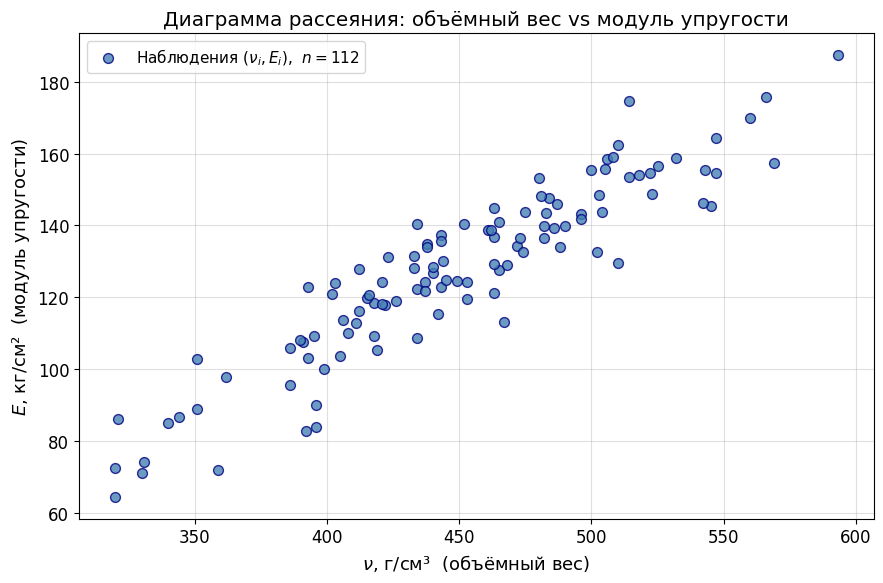

In [3]:
plt.figure(figsize=(9, 6))
plt.scatter(X, Y, color='steelblue', edgecolors='navy',
            s=50, alpha=0.8, zorder=5,
            label=f'Наблюдения $(\\nu_i, E_i)$,  $n={n}$')
plt.xlabel('$\\nu$, г/см³  (объёмный вес)', fontsize=13)
plt.ylabel('$E$, кг/см²  (модуль упругости)', fontsize=13)
plt.title('Диаграмма рассеяния: объёмный вес vs модуль упругости')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()


### Задание 2. Уравнения прямых среднеквадратической регрессии

In [4]:
x_mean = np.mean(X)
y_mean = np.mean(Y)
s_x    = np.std(X, ddof=1)   # несмещённое СКО
s_y    = np.std(Y, ddof=1)
r_xy   = np.corrcoef(X, Y)[0, 1]

print('Базовые характеристики выборки')
print(f'  n    = {n}')
print(f'  x̄    = {x_mean:.4f}  г/см³')
print(f'  ȳ    = {y_mean:.4f}  кг/см²')
print(f'  sₓ   = {s_x:.4f}')
print(f'  sᵧ   = {s_y:.4f}')
print(f'  r_xy = {r_xy:.4f}   (сильная положительная корреляция)')


b1_yx = r_xy * s_y / s_x
b0_yx = y_mean - b1_yx * x_mean

print('\nРегрессия E на ν  (Y на X)')
print(f'  b₁ = r · sᵧ/sₓ = {r_xy:.4f} · {s_y:.4f}/{s_x:.4f} = {b1_yx:.4f}')
print(f'  b₀ = ȳ − b₁·x̄  = {y_mean:.4f} − {b1_yx:.4f}·{x_mean:.4f} = {b0_yx:.4f}')
print(f'  >>> Ê = {b0_yx:.4f} + {b1_yx:.4f}·ν')


d1_xy = r_xy * s_x / s_y
d0_xy = x_mean - d1_xy * y_mean

print('\nРегрессия ν на E  (X на Y)')
print(f'  d₁ = r · sₓ/sᵧ = {r_xy:.4f} · {s_x:.4f}/{s_y:.4f} = {d1_xy:.4f}')
print(f'  d₀ = x̄ − d₁·ȳ  = {x_mean:.4f} − {d1_xy:.4f}·{y_mean:.4f} = {d0_xy:.4f}')
print(f'  >>> ν̂ = {d0_xy:.4f} + {d1_xy:.4f}·E')
print(f'  Для графика (выражена через ν): Ê = (ν − {d0_xy:.4f}) / {d1_xy:.4f}')

Базовые характеристики выборки
  n    = 112
  x̄    = 449.5179  г/см³
  ȳ    = 127.5080  кг/см²
  sₓ   = 59.2425
  sᵧ   = 24.4576
  r_xy = 0.9230   (сильная положительная корреляция)

Регрессия E на ν  (Y на X)
  b₁ = r · sᵧ/sₓ = 0.9230 · 24.4576/59.2425 = 0.3811
  b₀ = ȳ − b₁·x̄  = 127.5080 − 0.3811·449.5179 = -43.7880
  >>> Ê = -43.7880 + 0.3811·ν

Регрессия ν на E  (X на Y)
  d₁ = r · sₓ/sᵧ = 0.9230 · 59.2425/24.4576 = 2.2358
  d₀ = x̄ − d₁·ȳ  = 449.5179 − 2.2358·127.5080 = 164.4299
  >>> ν̂ = 164.4299 + 2.2358·E
  Для графика (выражена через ν): Ê = (ν − 164.4299) / 2.2358


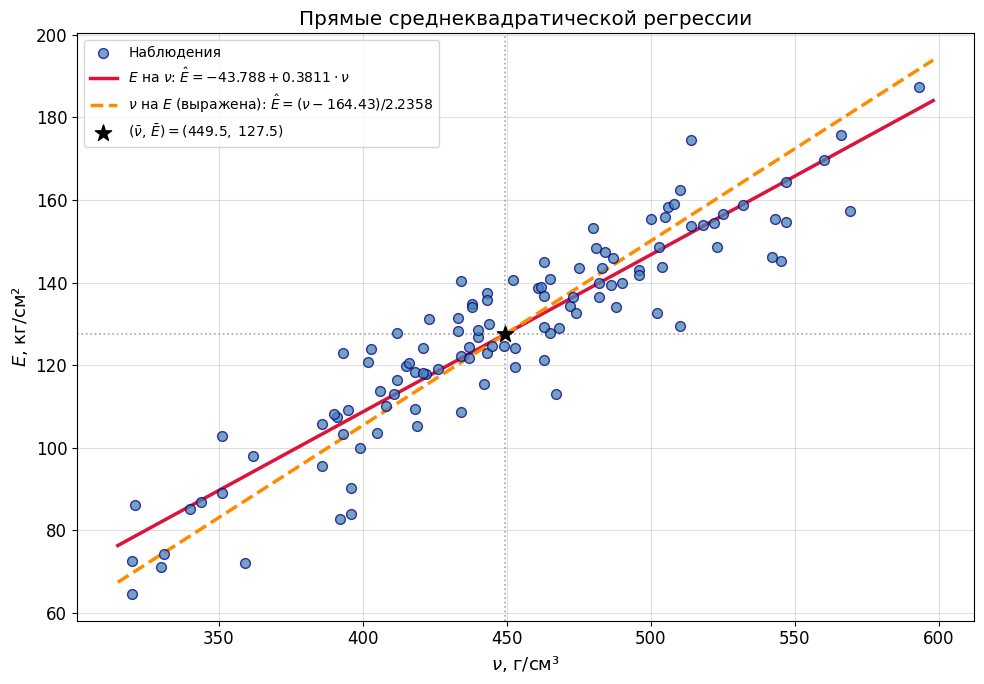

Обе прямые пересекаются в центре рассеяния (ν̄, Ē).
|r_xy| = 0.9230 < 1 — угол между прямыми ненулевой, зависимость неполная.


In [5]:
x_plot = np.linspace(X.min() - 5, X.max() + 5, 400)
y_reg_yx = b0_yx + b1_yx * x_plot
y_reg_xy = (x_plot - d0_xy) / d1_xy     # X на Y, выражена через x

plt.figure(figsize=(10, 7))
plt.scatter(X, Y, color='steelblue', edgecolors='navy',
            s=50, alpha=0.75, zorder=5, label='Наблюдения')
plt.plot(x_plot, y_reg_yx, color='crimson', lw=2.5,
         label=f'$E$ на $\\nu$: $\\hat{{E}} = {b0_yx:.3f} + {b1_yx:.4f}\\cdot\\nu$')
plt.plot(x_plot, y_reg_xy, color='darkorange', lw=2.5, linestyle='--',
         label=f'$\\nu$ на $E$ (выражена): $\\hat{{E}} = (\\nu - {d0_xy:.2f})/{d1_xy:.4f}$')
plt.scatter([x_mean], [y_mean], color='black', s=150, zorder=7,
            marker='*',
            label=f'$(\\bar{{\\nu}},\\, \\bar{{E}}) = ({x_mean:.1f},\\; {y_mean:.1f})$')
plt.axvline(x_mean, color='gray', linestyle=':', lw=1.2, alpha=0.7)
plt.axhline(y_mean, color='gray', linestyle=':', lw=1.2, alpha=0.7)
plt.xlabel('$\\nu$, г/см³', fontsize=13)
plt.ylabel('$E$, кг/см²', fontsize=13)
plt.title('Прямые среднеквадратической регрессии')
plt.legend(fontsize=10, loc='upper left')
plt.tight_layout()
plt.show()

print('Обе прямые пересекаются в центре рассеяния (ν̄, Ē).'
      f'\n|r_xy| = {abs(r_xy):.4f} < 1 — угол между прямыми ненулевой,'
      ' зависимость неполная.')

### Задание 3. Корреляционная таблица и выборочное корреляционное отношение


In [6]:
k = 14

x_bins = np.linspace(X.min(), X.max(), k + 1)
y_bins = np.linspace(Y.min(), Y.max(), k + 1)

x_group = np.clip(np.digitize(X, x_bins) - 1, 0, k - 1)
y_group = np.clip(np.digitize(Y, y_bins) - 1, 0, k - 1)

corr_mat = np.zeros((k, k), dtype=int)
for i in range(n):
    corr_mat[y_group[i], x_group[i]] += 1

x_lbl = [f'{x_bins[j]:.0f}–{x_bins[j+1]:.0f}' for j in range(k)]
y_lbl = [f'{y_bins[i]:.1f}–{y_bins[i+1]:.1f}' for i in range(k)]

ct = pd.DataFrame(corr_mat[::-1], index=y_lbl[::-1], columns=x_lbl)
ct['nᵢ•'] = ct.sum(axis=1)
totals = ct.sum(axis=0).rename('n•ⱼ')
ct_full = pd.concat([ct, totals.to_frame().T])

print(f'Корреляционная таблица (k = {k}, n = {n}):')
print(ct_full.to_string())
print(f'\nСумма всех частот: {corr_mat.sum()} (должна быть {n})')

Корреляционная таблица (k = 14, n = 112):
             320–340  340–359  359–378  378–398  398–418  418–437  437–456  456–476  476–496  496–515  515–534  534–554  554–574  574–593  nᵢ•
178.6–187.4        0        0        0        0        0        0        0        0        0        0        0        0        0        1    1
169.8–178.6        0        0        0        0        0        0        0        0        0        1        0        0        1        0    2
161.1–169.8        0        0        0        0        0        0        0        0        0        1        0        1        1        0    3
152.3–161.1        0        0        0        0        0        0        0        0        1        5        4        2        1        0   13
143.5–152.3        0        0        0        0        0        0        0        2        3        2        1        2        0        0   10
134.7–143.5        0        0        0        0        0        1        4        5        5        

In [7]:
D_y = np.var(Y, ddof=0)

n_j    = np.zeros(k, dtype=int)
y_cond = np.full(k, np.nan)
for j in range(k):
    idx = np.where(x_group == j)[0]
    if len(idx):
        n_j[j]    = len(idx)
        y_cond[j] = np.mean(Y[idx])

D_inter_yx = np.nansum(n_j * (y_cond - y_mean)**2) / n
eta_yx     = np.sqrt(D_inter_yx / D_y)


D_x = np.var(X, ddof=0)

n_i    = np.zeros(k, dtype=int)
x_cond = np.full(k, np.nan)
for i in range(k):
    idx = np.where(y_group == i)[0]
    if len(idx):
        n_i[i]    = len(idx)
        x_cond[i] = np.mean(X[idx])

D_inter_xy = np.nansum(n_i * (x_cond - x_mean)**2) / n
eta_xy     = np.sqrt(D_inter_xy / D_x)


tbl_yx = pd.DataFrame({
    'Интервал ν': x_lbl,
    'nⱼ':         n_j,
    'Ēⱼ (услов. ср. E|ν)': np.round(y_cond, 3)
})
print('Условные средние Ēⱼ по группам ν:')
print(tbl_yx.to_string(index=False))

print()
print(f'D_y              = {D_y:.4f}')
print(f'D_межгр(E|ν)     = {D_inter_yx:.4f}')
print(f'η_yx = √(D_межгр/D_y) = {eta_yx:.4f}')
print()
print(f'D_x              = {D_x:.4f}')
print(f'D_межгр(ν|E)     = {D_inter_xy:.4f}')
print(f'η_xy = √(D_межгр/D_x) = {eta_xy:.4f}')
print()
print(f'|r_xy|           = {abs(r_xy):.4f}')
print()
print(f'Проверка η_yx ≥ |r_xy|: {eta_yx:.4f} ≥ {abs(r_xy):.4f}  →  {eta_yx >= abs(r_xy)}')
print(f'Проверка η_xy ≥ |r_xy|: {eta_xy:.4f} ≥ {abs(r_xy):.4f}  →  {eta_xy >= abs(r_xy)}')

Условные средние Ēⱼ по группам ν:
Интервал ν  nⱼ  Ēⱼ (услов. ср. E|ν)
   320–340   5               73.680
   340–359   4               90.950
   359–378   2               84.900
   378–398  10              100.860
   398–418  11              115.391
   418–437  13              121.100
   437–456  16              127.819
   456–476  14              133.329
   476–496  10              142.820
   496–515  13              150.631
   515–534   5              154.480
   534–554   5              153.180
   554–574   3              167.633
   574–593   1              187.400

D_y              = 592.8311
D_межгр(E|ν)     = 516.3844
η_yx = √(D_межгр/D_y) = 0.9333

D_x              = 3478.3390
D_межгр(ν|E)     = 2983.9081
η_xy = √(D_межгр/D_x) = 0.9262

|r_xy|           = 0.9230

Проверка η_yx ≥ |r_xy|: 0.9333 ≥ 0.9230  →  True
Проверка η_xy ≥ |r_xy|: 0.9262 ≥ 0.9230  →  True


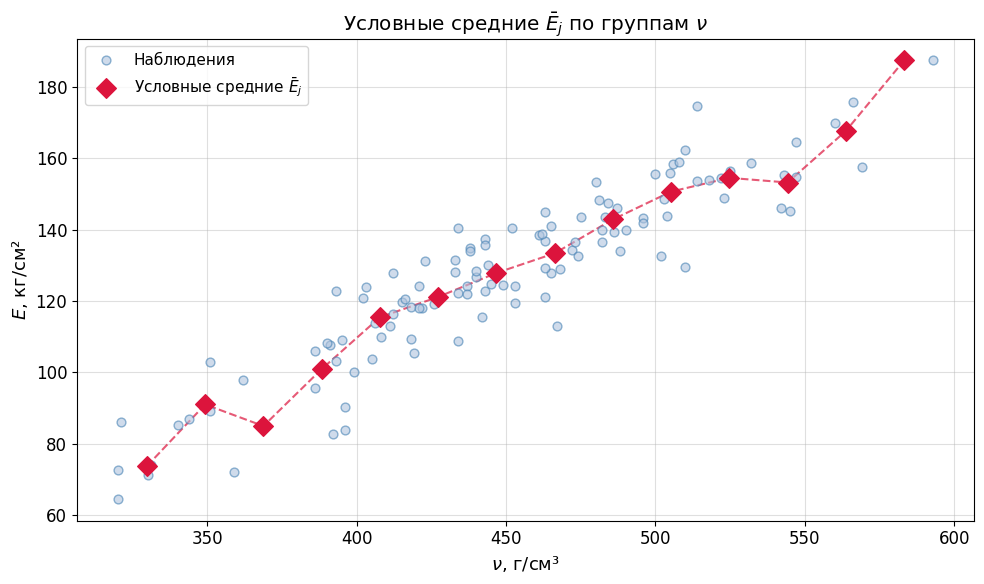

In [8]:

x_centers = 0.5 * (x_bins[:-1] + x_bins[1:])

plt.figure(figsize=(10, 6))
plt.scatter(X, Y, color='lightsteelblue', edgecolors='steelblue',
            s=40, alpha=0.6, zorder=3, label='Наблюдения')
plt.scatter(x_centers, y_cond, color='crimson', s=100, zorder=6,
            marker='D', label='Условные средние $\\bar{E}_j$')
plt.plot(x_centers, y_cond, color='crimson', lw=1.5,
         linestyle='--', alpha=0.7)
plt.xlabel('$\\nu$, г/см³', fontsize=13)
plt.ylabel('$E$, кг/см²', fontsize=13)
plt.title('Условные средние $\\bar{E}_j$ по группам $\\nu$')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

### Задание 4. Параболическая корреляционная кривая $\hat{E} = \beta_0 + \beta_1 \nu + \beta_2 \nu^2$

Параболическая регрессия:  Ê = β₀ + β₁ν + β₂ν²
  β₀ = -132.4424
  β₁ = 0.7846
  β₂ = -0.000451

  Ê = -132.4424 +0.7846·ν -0.000451·ν²

  R²  = 0.8590
  Sε  = 9.2667  кг/см²
  A   = 5.97%


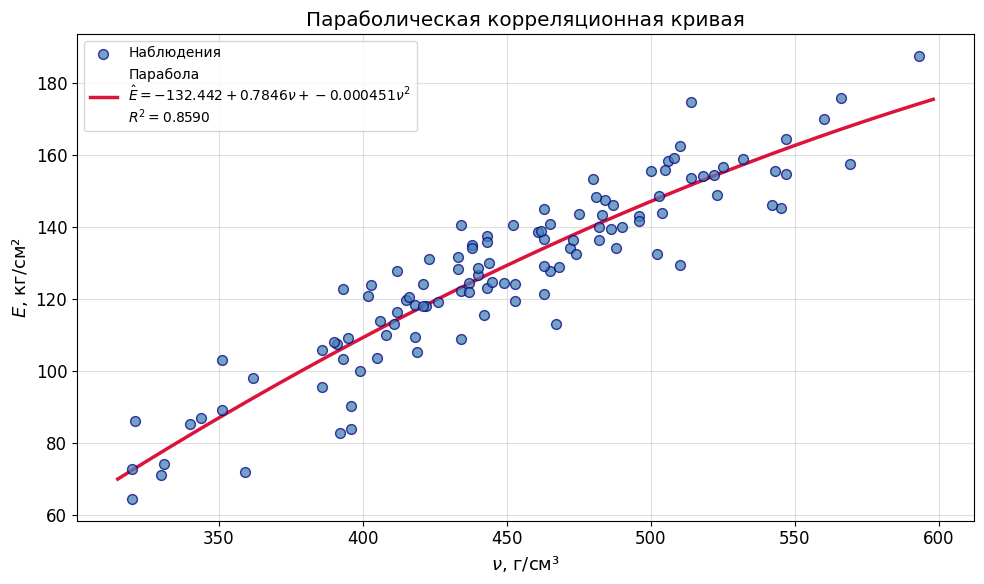

In [9]:

A_p  = np.column_stack([np.ones(n), X, X**2])
beta_p, _, _, _ = np.linalg.lstsq(A_p, Y, rcond=None)
b0_p, b1_p, b2_p = beta_p

Y_hat_p  = A_p @ beta_p
SS_tot   = np.sum((Y - y_mean)**2)
SS_res_p = np.sum((Y - Y_hat_p)**2)
R2_p     = 1 - SS_res_p / SS_tot
Se_p     = np.sqrt(SS_res_p / (n - 3))
A_p_err  = np.mean(np.abs((Y - Y_hat_p) / Y)) * 100

print('Параболическая регрессия:  Ê = β₀ + β₁ν + β₂ν²')
print(f'  β₀ = {b0_p:.4f}')
print(f'  β₁ = {b1_p:.4f}')
print(f'  β₂ = {b2_p:.6f}')
sign1 = '+' if b1_p >= 0 else ''
sign2 = '+' if b2_p >= 0 else ''
print(f'\n  Ê = {b0_p:.4f} {sign1}{b1_p:.4f}·ν {sign2}{b2_p:.6f}·ν²')
print(f'\n  R²  = {R2_p:.4f}')
print(f'  Sε  = {Se_p:.4f}  кг/см²')
print(f'  A   = {A_p_err:.2f}%')

y_para_plt = b0_p + b1_p*x_plot + b2_p*x_plot**2

plt.figure(figsize=(10, 6))
plt.scatter(X, Y, color='steelblue', edgecolors='navy',
            s=50, alpha=0.75, zorder=5, label='Наблюдения')
plt.plot(x_plot, y_para_plt, color='crimson', lw=2.5,
         label=f'Парабола\n$\\hat{{E}} = {b0_p:.3f} + {b1_p:.4f}\\nu + {b2_p:.6f}\\nu^2$\n'
               f'$R^2 = {R2_p:.4f}$')
plt.xlabel('$\\nu$, г/см³', fontsize=13)
plt.ylabel('$E$, кг/см²', fontsize=13)
plt.title('Параболическая корреляционная кривая')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

Параболическая модель $\hat{E} = \beta_0 + \beta_1\nu + \beta_2\nu^2$: коэффициент $\beta_2 \approx -0.000451$ очень мал по модулю, а $R^2$ почти совпадает с линейным вариантом. Парабола незначительно улучшает подгонку по сравнению с прямой, что согласуется с выводом о преобладающей линейности данных.

### Задание 5. Степенная корреляционная кривая $\hat{E} = \beta_0 \cdot \nu^{\beta_1}$

Линеаризация логарифмированием:
$$\ln E = \ln\beta_0 + \beta_1 \ln\nu \quad\Longrightarrow\quad E' = a + \beta_1\, \nu', \quad E' = \ln E,\ \nu' = \ln\nu,\ a = \ln\beta_0$$
МНК применяется в пространстве $(\ln\nu,\, \ln E)$, затем $\beta_0 = e^a$.

Степенная регрессия:  Ê = β₀·νᵝ¹
  Линеаризованная форма: ln(Ê) = -3.8660 + 1.4254·ln(ν)
  β₀ = exp(-3.8660) = 0.020942
  β₁ = 1.4254

  Ê = 0.020942·ν^1.4254

  R²  = 0.8426
  Sε  = 9.7482  кг/см²
  A   = 6.30%


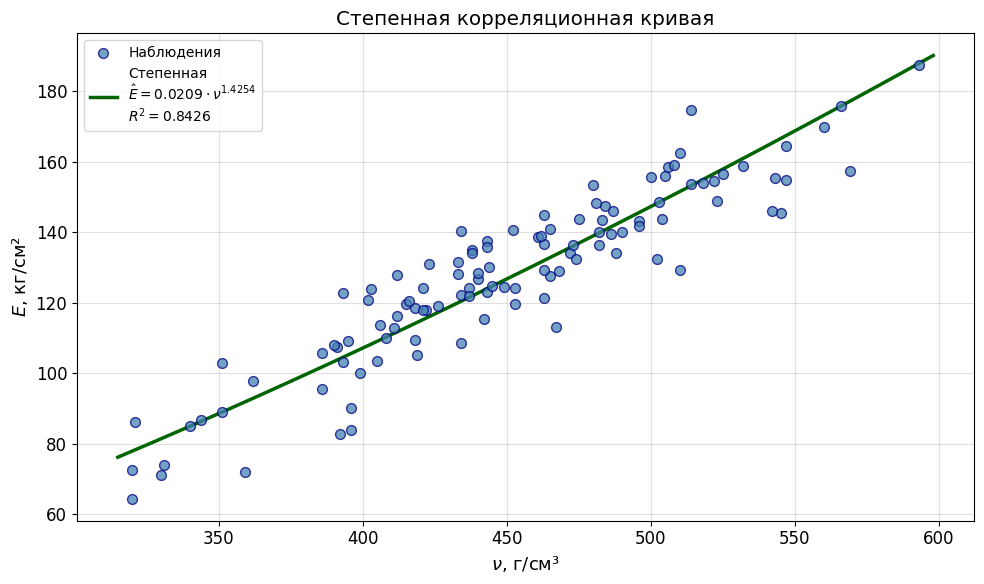

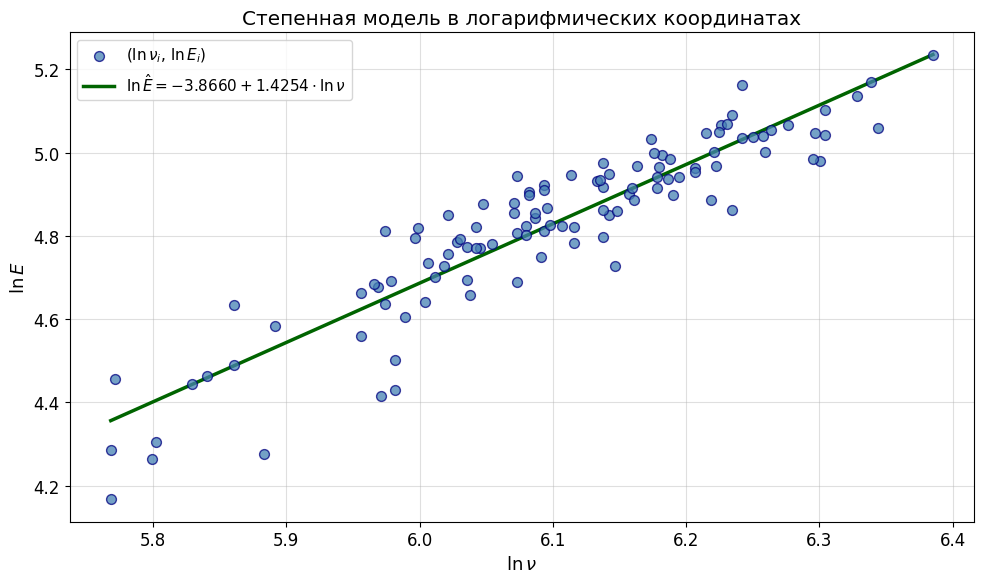

In [10]:
ln_X = np.log(X)
ln_Y = np.log(Y)   

# МНК для ln(E) = a + β₁·ln(ν)
A_w = np.column_stack([np.ones(n), ln_X])
c, _, _, _ = np.linalg.lstsq(A_w, ln_Y, rcond=None)
a_ln, b1_w = c
b0_w = np.exp(a_ln)

print('Степенная регрессия:  Ê = β₀·νᵝ¹')
print(f'  Линеаризованная форма: ln(Ê) = {a_ln:.4f} + {b1_w:.4f}·ln(ν)')
print(f'  β₀ = exp({a_ln:.4f}) = {b0_w:.6f}')
print(f'  β₁ = {b1_w:.4f}')
print(f'\n  Ê = {b0_w:.6f}·ν^{b1_w:.4f}')

Y_hat_w  = b0_w * X**b1_w
SS_res_w = np.sum((Y - Y_hat_w)**2)
R2_w     = 1 - SS_res_w / SS_tot
Se_w     = np.sqrt(SS_res_w / (n - 2))
A_w_err  = np.mean(np.abs((Y - Y_hat_w) / Y)) * 100

print(f'\n  R²  = {R2_w:.4f}')
print(f'  Sε  = {Se_w:.4f}  кг/см²')
print(f'  A   = {A_w_err:.2f}%')

y_pow_plt = b0_w * x_plot**b1_w


plt.figure(figsize=(10, 6))
plt.scatter(X, Y, color='steelblue', edgecolors='navy',
            s=50, alpha=0.75, zorder=5, label='Наблюдения')
plt.plot(x_plot, y_pow_plt, color='darkgreen', lw=2.5,
         label=f'Степенная\n$\\hat{{E}} = {b0_w:.4f}\\cdot\\nu^{{{b1_w:.4f}}}$\n'
               f'$R^2 = {R2_w:.4f}$')
plt.xlabel('$\\nu$, г/см³', fontsize=13)
plt.ylabel('$E$, кг/см²', fontsize=13)
plt.title('Степенная корреляционная кривая')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

x_ln_plt = np.linspace(ln_X.min(), ln_X.max(), 200)
plt.figure(figsize=(10, 6))
plt.scatter(ln_X, ln_Y, color='steelblue', edgecolors='navy',
            s=50, alpha=0.75, zorder=5,
            label='$(\\ln\\nu_i,\\, \\ln E_i)$')
plt.plot(x_ln_plt, a_ln + b1_w*x_ln_plt, color='darkgreen', lw=2.5,
         label=f'$\\ln\\hat{{E}} = {a_ln:.4f} + {b1_w:.4f}\\cdot\\ln\\nu$')
plt.xlabel('$\\ln\\nu$', fontsize=13)
plt.ylabel('$\\ln E$', fontsize=13)
plt.title('Степенная модель в логарифмических координатах')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()


Показатель степени $\beta_1 \approx 1.43 > 1$ — зависимость $E$ от $\nu$ нарастает быстрее линейной.

В логарифмических координатах $(\ln\nu,\, \ln E)$ точки ложатся вдоль прямой, что подтверждает правомерность степенной формы.

По $R^2$ и $S_\varepsilon$ степенная модель несколько уступает линейной и параболической, что означает: для данного диапазона наблюдений линейная аппроксимация является более точной.

### Задание 6. Сводная таблица показателей качества

Показатели качества регрессионных моделей:
             Модель                            Уравнение     R²     Sε A, %
           Линейная               Ê = -43.788 + 0.3811·ν 0.8520 9.4516 6.12
     Параболическая Ê = -132.442 + 0.7846ν + -0.000451ν² 0.8590 9.2667 5.97
Степенная (вар. 1а)                  Ê = 0.0209·ν^1.4254 0.8426 9.7482 6.30


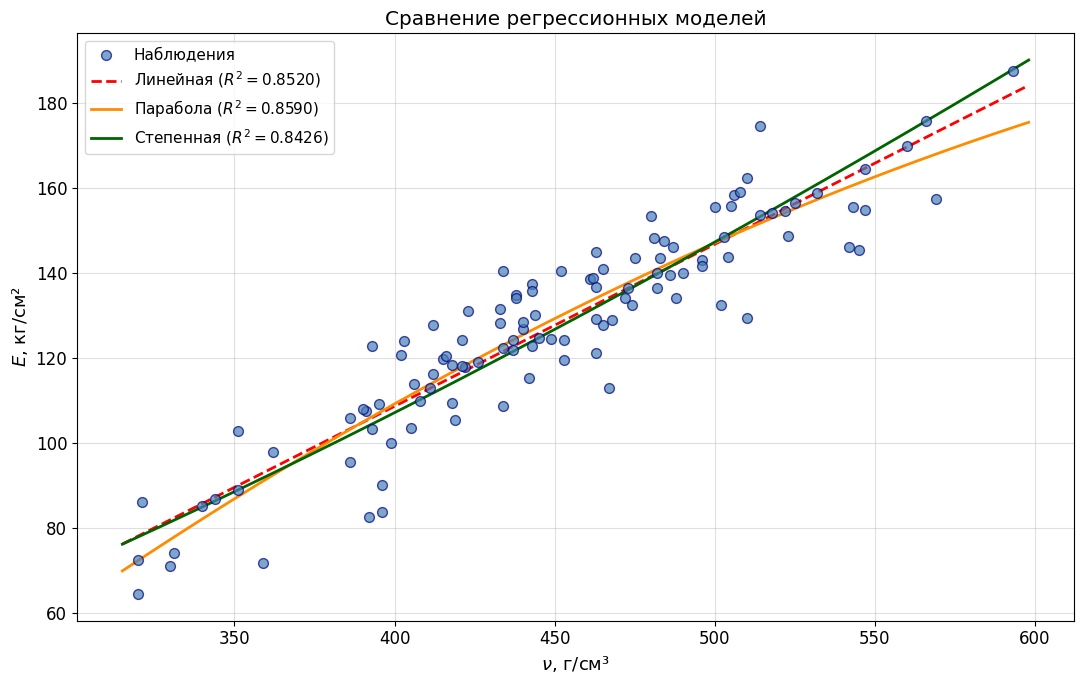

In [ ]:
Y_hat_lin = b0_yx + b1_yx * X
SS_res_l  = np.sum((Y - Y_hat_lin)**2)
R2_l      = 1 - SS_res_l / SS_tot
Se_l      = np.sqrt(SS_res_l / (n - 2))
A_l       = np.mean(np.abs((Y - Y_hat_lin) / Y)) * 100

quality = pd.DataFrame({
    'Модель': ['Линейная', 'Параболическая', 'Степенная (вар. 1а)'],
    'Уравнение': [
        f'Ê = {b0_yx:.3f} + {b1_yx:.4f}·ν',
        f'Ê = {b0_p:.3f} + {b1_p:.4f}ν + {b2_p:.6f}ν²',
        f'Ê = {b0_w:.4f}·ν^{b1_w:.4f}'
    ],
    'R²':    [f'{R2_l:.4f}',     f'{R2_p:.4f}',     f'{R2_w:.4f}'],
    'Sε':    [f'{Se_l:.4f}',     f'{Se_p:.4f}',     f'{Se_w:.4f}'],
    'A, %':  [f'{A_l:.2f}',      f'{A_p_err:.2f}',  f'{A_w_err:.2f}']
})
print('Показатели качества регрессионных моделей:')
print(quality.to_string(index=False))


plt.figure(figsize=(11, 7))
plt.scatter(X, Y, color='steelblue', edgecolors='navy',
            s=50, alpha=0.7, zorder=5, label='Наблюдения')
plt.plot(x_plot, b0_yx + b1_yx*x_plot, 'r--', lw=2,
         label=f'Линейная ($R^2={R2_l:.4f}$)')
plt.plot(x_plot, b0_p + b1_p*x_plot + b2_p*x_plot**2,
         color='darkorange', lw=2,
         label=f'Парабола ($R^2={R2_p:.4f}$)')
plt.plot(x_plot, b0_w*x_plot**b1_w, color='darkgreen', lw=2,
         label=f'Степенная ($R^2={R2_w:.4f}$)')
plt.xlabel('$\\nu$, г/см³', fontsize=13)
plt.ylabel('$E$, кг/см²', fontsize=13)
plt.title('Сравнение регрессионных моделей')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

### Выводы

Между объёмным весом $\nu$ и модулем упругости $E$ резонансной ели существует сильная положительная зависимость ($r_{xy} \approx 0.923$). Все три модели дают сопоставимое качество аппроксимации ($R^2 \approx 0.84$–$0.86$, $A \approx 6\%$). Линейная и параболическая модели описывают данные несколько точнее степенной на данном наблюдаемом диапазоне. Степенная модель содержательно интерпретируется как указание на более интенсивный рост прочностных характеристик с увеличением плотности древесины.